In [11]:
import warnings
warnings.filterwarnings('ignore')

import json, os
notebook_path = 'NLP_Experiment.ipynb'

In [1]:
!pip install transformers torch scikit-learn pandas -q

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "suchintikasarkar/sentiment-analysis-for-mental-health",
    "Combined Data.csv",
)

print(f"Loaded {len(df):,} rows")
print("Columns:", df.columns.tolist())
print("First 5 records:")
df.head()

/tmp/ipykernel_525/3259718750.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'sentiment-analysis-for-mental-health' dataset.
Loaded 53,043 rows
Columns: ['Unnamed: 0', 'statement', 'status']
First 5 records:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
import pandas as pd, re

df = df[['statement', 'status']].dropna().drop_duplicates()

df_sample = (df.groupby('status', group_keys=False)
               .apply(lambda x: x.sample(min(len(x), 150), random_state=42)))

def clean(text):
    text = re.sub(r'httpS+', '', str(text))
    text = re.sub(r'@w+|#w+', '', text)
    return re.sub(r's+', ' ', text).strip().lower()

df_sample['clean_text'] = df_sample['statement'].apply(clean)
print(df_sample['status'].value_counts())

status
Anxiety                 150
Bipolar                 150
Depression              150
Normal                  150
Personality disorder    150
Stress                  150
Suicidal                150
Name: count, dtype: int64


/tmp/ipykernel_525/720432882.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 150), random_state=42)))


In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df_sample['label'] = le.fit_transform(df_sample['status'])

train_val_df, test_df = train_test_split(
    df_sample, test_size=0.2, random_state=42,
    stratify=df_sample['label']
)

train_df, val_df = train_test_split(
    train_val_df, test_size=0.15, random_state=42,
    stratify=train_val_df['label']
)

print(f'Train : {len(train_df)} rows')
print(f'Val   : {len(val_df)} rows')
print(f'Test  : {len(test_df)} rows')
print('Classes:', list(le.classes_))

Train : 714 rows
Val   : 126 rows
Test  : 210 rows
Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
import warnings
warnings.filterwarnings('ignore')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class MHDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = tokenizer(self.texts[i], max_length=128,
                        truncation=True, padding='max_length',
                        return_tensors='pt')
        return {k: v.squeeze(0) for k, v in enc.items()} | {'label': torch.tensor(self.labels[i])}

train_dl = DataLoader(MHDataset(train_df['clean_text'], train_df['label']), batch_size=16, shuffle=True)
val_dl   = DataLoader(MHDataset(val_df['clean_text'],   val_df['label']),   batch_size=16)
test_dl  = DataLoader(MHDataset(test_df['clean_text'],  test_df['label']),  batch_size=16)

print(f'Train batches: {len(train_dl)}')
print(f'Val batches  : {len(val_dl)}')
print(f'Test batches : {len(test_dl)}')

Train batches: 45
Val batches  : 8
Test batches : 14


In [15]:
import torch.nn as nn
from transformers import BertModel

class MultiTaskBERT(nn.Module):
    def __init__(self, n_status=7, n_sentiment=3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(0.3)
        self.status_head    = nn.Linear(768, n_status)
        self.sentiment_head = nn.Linear(768, n_sentiment)

    def forward(self, input_ids, attention_mask, token_type_ids):
        out    = self.bert(input_ids, attention_mask, token_type_ids)
        pooled = self.drop(out.pooler_output)
        return self.status_head(pooled), self.sentiment_head(pooled)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MultiTaskBERT().to(device)
print('Model ready on', device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready on cuda


In [16]:
from torch.optim import AdamW

opt = AdamW(model.parameters(), lr=2e-5)
loss_fn  = nn.CrossEntropyLoss()
train_losses = []

for epoch in range(3):
    model.train()
    epoch_loss = 0

    for batch in train_dl:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        tt   = batch['token_type_ids'].to(device)
        labs = batch['label'].to(device)

        status_logits, _ = model(ids, mask, tt)
        loss = loss_fn(status_logits, labs)

        opt.zero_grad()
        loss.backward()
        opt.step()

        epoch_loss += loss.item()

    avg = epoch_loss / len(train_dl)
    train_losses.append(avg)
    print(f'Epoch {epoch+1}/3  |  loss: {avg:.4f}')


Epoch 1/3  |  loss: 1.8798
Epoch 2/3  |  loss: 1.6663
Epoch 3/3  |  loss: 1.3296


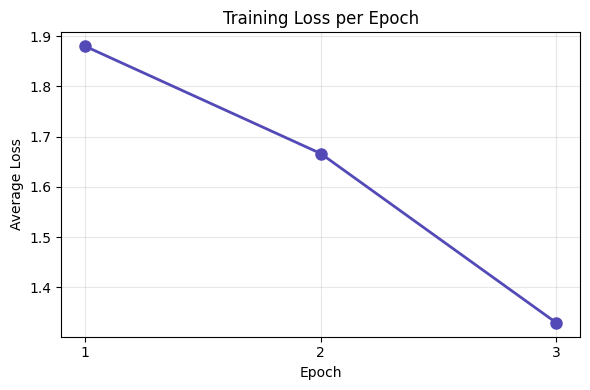

Saved: training_loss.png


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], train_losses, 'o-', color='#534AB7', linewidth=2, markersize=8)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks([1, 2, 3])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
print('Saved: training_loss.png')

In [18]:
from sklearn.metrics import classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_dl:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        tt   = batch['token_type_ids'].to(device)

        logits, _ = model(ids, mask, tt)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(batch['label'].numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    zero_division=0
))

                      precision    recall  f1-score   support

             Anxiety       0.77      0.33      0.47        30
             Bipolar       0.54      0.67      0.60        30
          Depression       0.73      0.27      0.39        30
              Normal       0.73      0.90      0.81        30
Personality disorder       0.66      0.63      0.64        30
              Stress       0.50      0.50      0.50        30
            Suicidal       0.53      0.93      0.67        30

            accuracy                           0.60       210
           macro avg       0.64      0.60      0.58       210
        weighted avg       0.64      0.60      0.58       210



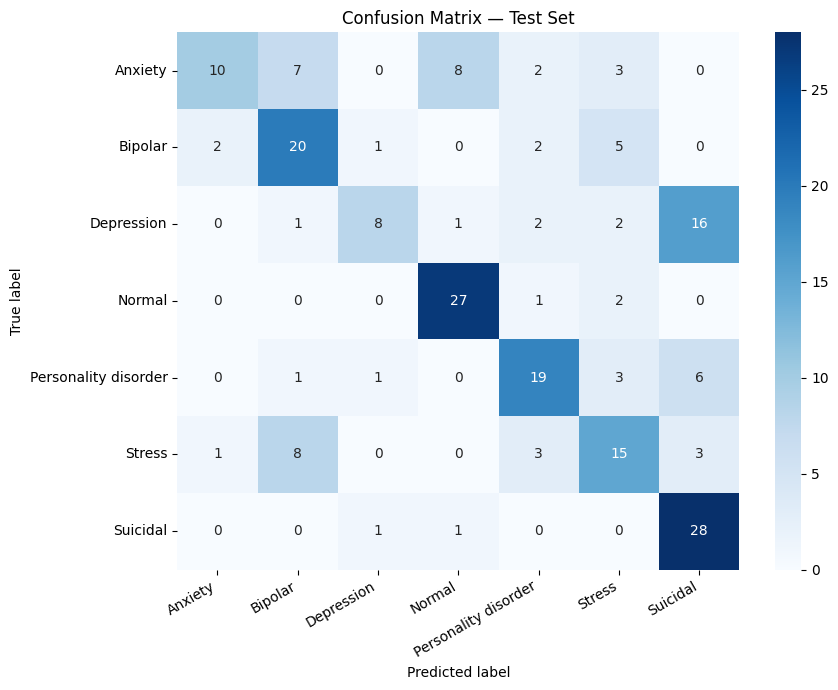

Saved: confusion_matrix.png


In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')